In [7]:
from ultralytics import YOLO

modelv8s = YOLO("8s.pt")
modelv9m = YOLO("9m.pt")
resultv8s = modelv8s("temp_image.jpg", verbose=False)
resultv9m = modelv9m("temp_image.jpg", verbose=False)

print(resultv8s[0].speed)
print(resultv9m[0].speed)

{'preprocess': 2.1477200025401544, 'inference': 6.997832999331877, 'postprocess': 1.5306919995055068}
{'preprocess': 1.787039996997919, 'inference': 26.229483999486547, 'postprocess': 3.078220001043519}


In [19]:
import os
from ultralytics import YOLO
from tqdm import tqdm
import numpy as np

# 모델 로드
modelv8s = YOLO("8s.pt")
modelv9m = YOLO("9m.pt")

# 이미지 폴더
image_folder = "images"
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.lower().endswith(".png")]

# 시간 기록용 리스트
def get_speed_stats(model, model_name, image_files):
    preprocess_times = []
    inference_times = []
    postprocess_times = []

    for img_path in tqdm(image_files, desc=f"Running {model_name}"):
        result = model(img_path, verbose=False)[0]
        speed = result.speed
        preprocess_times.append(speed['preprocess'])
        inference_times.append(speed['inference'])
        postprocess_times.append(speed['postprocess'])

    return {
        "preprocess_avg": np.mean(preprocess_times),
        "inference_avg": np.mean(inference_times),
        "postprocess_avg": np.mean(postprocess_times),
        "total_avg": np.mean(preprocess_times) + np.mean(inference_times) + np.mean(postprocess_times)
    }

# 측정
stats_v8s = get_speed_stats(modelv8s, "YOLOv8s", image_files)
stats_v9m = get_speed_stats(modelv9m, "YOLOv9m", image_files)

# 출력
def print_stats(model_name, stats):
    print(f"\n📊 {model_name} 평균 속도 (ms):")
    print(f"  Preprocess   : {stats['preprocess_avg']:.2f}")
    print(f"  Inference    : {stats['inference_avg']:.2f}")
    print(f"  Postprocess  : {stats['postprocess_avg']:.2f}")
    print(f"  ✅ Total Avg  : {stats['total_avg']:.2f}")

print_stats("YOLOv8s", stats_v8s)
print_stats("YOLOv9m", stats_v9m)


Running YOLOv9m: 100%|██████████| 200/200 [00:04<00:00, 41.10it/s]


📊 YOLOv8s 평균 속도 (ms):
  Preprocess   : 1.48
  Inference    : 7.44
  Postprocess  : 1.88
  ✅ Total Avg  : 10.81

📊 YOLOv9m 평균 속도 (ms):
  Preprocess   : 1.48
  Inference    : 14.30
  Postprocess  : 1.88
  ✅ Total Avg  : 17.66


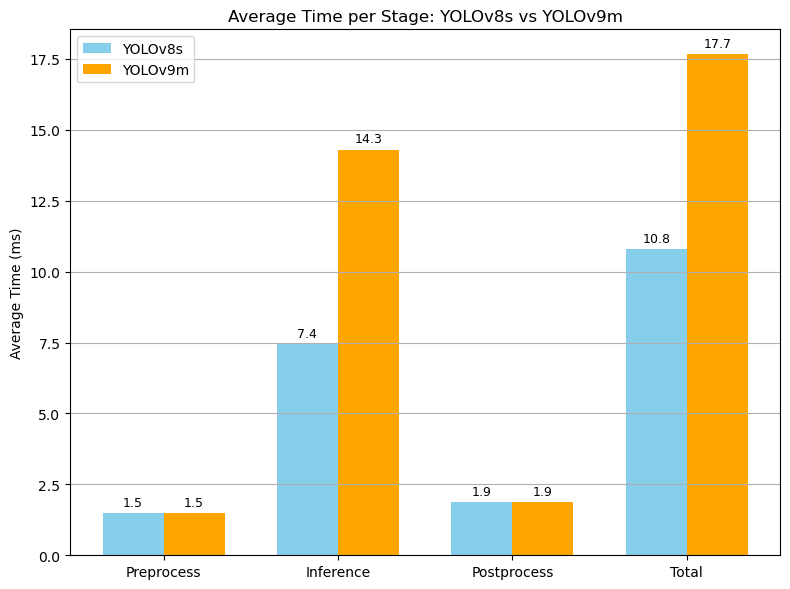

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 각 항목별 평균값
labels = ["Preprocess", "Inference", "Postprocess", "Total"]
v8s_means = [
    stats_v8s["preprocess_avg"],
    stats_v8s["inference_avg"],
    stats_v8s["postprocess_avg"],
    stats_v8s["total_avg"]
]
v9m_means = [
    stats_v9m["preprocess_avg"],
    stats_v9m["inference_avg"],
    stats_v9m["postprocess_avg"],
    stats_v9m["total_avg"]
]

# x 위치 설정
x = np.arange(len(labels))
width = 0.35  # 막대 너비

# 그래프 그리기
fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, v8s_means, width, label='YOLOv8s', color='skyblue')
bars2 = ax.bar(x + width/2, v9m_means, width, label='YOLOv9m', color='orange')

# 라벨 설정
ax.set_ylabel("Average Time (ms)")
ax.set_title("Average Time per Stage: YOLOv8s vs YOLOv9m")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, axis='y')

# 막대 위에 값 표시
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()
